# Seizure Prediction on Pediatric Epilepsy Data

The goal of this project is to 
1) Build a CNN to predict seizures given a pre-ictal window of 15 minute, 30 mintues, and 45 minutes on a patient spceific level and compare their sensitivities and recall. 
2) Observe how seizure morphology and power spectral density vary across seizures in the dataset I am using and using Jenseno-Shannon divergence to compare them as well using a pre-ictal window of 30 minutes.

My methods are: 
1) A 1 dimensional CNN for seizure prediction across pre-ictal windows. The baseline model for this will be an Autoregressive model. I will build AR models for interictal and pre-ictal segments. 

2) Plot the power spectral densities for pre-ictal (defined as 30 minutes for this analysis) and ictal stages. I will then use Jensen-Shannon divergence to compare the stages and patients. 


First, install all of the appropriate libraries for this analysis 
Pandas, numpy, torch, scipy, matplot lib, and seaborn are necessary for data analysis and visualization 
mne is necessary in order to preprocess the epilepsy data. This is a common package used in EEG analysis in python and was recommened by Professor Hamilton during office hours as well

In [48]:
!pip install mne wfdb torch scikit-learn scipy numpy pandas matplotlib seaborn

DEPRECATION: Loading egg at /Users/hannahaguilar/miniconda3/lib/python3.11/site-packages/sortedcontainers-2.4.0-py3.11.egg is deprecated. pip 24.3 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at /Users/hannahaguilar/miniconda3/lib/python3.11/site-packages/networkx-3.4.2-py3.11.egg is deprecated. pip 24.3 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at /Users/hannahaguilar/miniconda3/lib/python3.11/site-packages/seaborn-0.13.2-py3.11.egg is deprecated. pip 24.3 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at /Users/hannahaguilar/miniconda3/lib/python3.11

Load in appropritate libraries.
These are the ones we saw in class commonly.
I added the welch and jensenshannon distance packages for answer my second question of interest

In [49]:
import os
import mne
import wfdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.signal import stft, welch
from scipy.spatial.distance import jensenshannon
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve)
from sklearn.linear_model import LogisticRegression
import torch
from torch import nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import glob
from statsmodels.tsa.ar_model import AutoReg
from scipy.signal import welch
from scipy.spatial.distance import jensenshannon


%matplotlib inline

In [50]:
#First for easy data loading, I must set the directories the data is in 

#Please adjust this directory as needed for your own purposes 
directory = Path("/Users/hannahaguilar/Desktop/stat248_final_project/physionet.org/files/chbmit/1.0.0")

I chose to only select two subjects for this analysis as suggested by the professor in the proposal comments. I chose subjects with 7 seizures for my models as well as because of limitations of compute power. For each of the subjects with 7 or more seizures, I looked at how spaced out their seizure files were in order to be able to compare pre-icatal windows of different lengths for my seizure prediction model manually within the data folders. 

In [51]:
#I saved the seizure records in my downloads, there was no header so header must be set to none. For easy naming purposes I set the name to be "directory" as it seems most appropriate 
seizure_dat = pd.read_csv("/Users/hannahaguilar/Downloads/RECORDS-WITH-SEIZURES.txt", sep = "\t", header = None, names = ["directory"])
seizure_dat2 = seizure_dat["directory"].str.split(pat = "/", expand = True)
seizure_dat2[0].value_counts().reset_index()
seizure_dat

,directory
0,chb01/chb01_03.edf
1,chb01/chb01_04.edf
2,chb01/chb01_15.edf
3,chb01/chb01_16.edf
4,chb01/chb01_18.edf
...,...
136,chb24/chb24_13.edf
137,chb24/chb24_14.edf
138,chb24/chb24_15.edf
139,chb24/chb24_17.edf


Based on my selection, I decided to use subjects 01 and 03

In [52]:
subjects = ["chb01", "chb03"]

This data was sampled at 256 Hz.

In [53]:
freq = 256

During office hours, Professor Hamilton and I discussed high and low frequency filters for this data set and we decided to use a low frequency filter of 0.5 Hz and a high frequency hilter of 15 Hz for my analysis. 

In [54]:
low_freq = 0.5
high_freq = 15
#Although it is not fully necessary, a common filter for EEG data collected in American institutions is a notch filter at 60 Hz
notch_freq = 60 

For model 1, I want to compare how well the model performs given different pre-ictal windows for the patients in my analysis (15 minutes, 30 minutes, and 45 minutes)

In [55]:
#The data is in seconds so to get 15 minutes I need to multiply 15*60, etc. for other window lengths
pre_ictal_windows = {
    "15": 15*60,
    "30": 30*60,
    "45": 45*60}

## Data loading

Note: This is code that is inspired by the MNE Python documentation source Professor Hamilton provided me during office hours: 
https://mne.tools/stable/auto_tutorials/preprocessing/index.html 
This documentation helped me with the pre-processing and data proessing steps as it was my first time working with EEG data. 

In [56]:
def data_loading(subject): 
    """ 
    The purpose of this function is to load in the data from the two subjects selected from this analysis. 
    INPUT: subject number 
    OUTPUT: the data for the subject in a dataframe form for easy python analysis in pandas. The output columns will include 
    the subject number, the file the data is coming from (each subject has 9-42 files in the overall dataset), the onset time of a seizure, the offset 
    time of a seizure, and the duration of a seizure. These times are all in seconds.  
    """
    subject_specific_information = seizure_dat[seizure_dat["directory"].str.startswith(subject)]["directory"].tolist()
    data = pd.DataFrame(columns = ["subject", "file", "onset_time", "offset_time", "duration_time"])
    for file_p in subject_specific_information:
        ann = wfdb.rdann(str(directory / subject / Path(file_p).stem), "edf.seizures")
        for i in range(0, len(ann.sample)-1, 2):
            start = ann.sample[i]/freq  #this gives sample indices we need for the start and end points 
            end = ann.sample[i+1]/freq
            data.loc[len(data)] = [subject, Path(file_p).stem, start, end, end-start]
    return data
    

In [57]:
full_data_frame = pd.concat([data_loading(subject) for subject in subjects])
full_data_frame.head()

,subject,file,onset_time,offset_time,duration_time
0,chb01,chb01_03,2996.0,3036.0,40.0
1,chb01,chb01_04,1467.0,1494.0,27.0
2,chb01,chb01_15,1732.0,1772.0,40.0
3,chb01,chb01_16,1015.0,1066.0,51.0
4,chb01,chb01_18,1720.0,1810.0,90.0


In [58]:
def load_in_edf_files(file_path):
    """  
    Now that we have a list of the files we need above, we should load in the actual edf files usign this function. 
    This function will also do the low and high frequency filtering. I followed similar code the the MNE Python documentation for this function. 
    Professor Hamilton told me to remove the data impacted by blinks which are several channels that involve the frontal lobe.
    INPUT: file path where the data is 
    OUTPUT: a dataframe with the subject's information
    """
    raw = mne.io.read_raw(str(file_path), preload = True)
    raw.filter(low_freq, high_freq)
    raw.notch_filter(notch_freq)
    df = raw.to_data_frame()
    df = df[['time', 'T7-P7', 'P7-O1', 'F3-C3', 'C3-P3',
             'P3-O1', 'F4-C4', 'C4-P4', 'P4-O2', 'T8-P8-0', 'P8-O2',
             'FZ-CZ', 'CZ-PZ', 'P7-T7', 'T8-P8-1']]
    return df


# Data Processing

Now that the data is all loaded in, it is time to extract the preictal windows from the edf files

In [59]:
def extract_preictal_window(subject, file_name, start, end):
    """    
    This will extract the particular preictal windows needed from each subject from their edf files 
    INPUT: subject of interest, file names, start and end times based on when the seizures are. 
    OUTPUT = a dataframe with the preictal information 
    """
    df = load_in_edf_files(directory / subject / (file_name+ ".edf"))
    
    if start >= 0:
        data = df[(df['time'] >= start) & (df['time'] < end)]
    else:
        prev_stem = f"{subject}_{str(int(file_name.split('_')[1]) - 1).zfill(2)}" #note for this particular line I needed to use online tools to debug because my code wasn't wokring 
        df_prev = load_in_edf_files(directory / subject / (prev_stem + ".edf"))
        data = pd.concat([df_prev[df_prev['time'] >= df_prev['time'].max() + start], df[df['time'] < end]])
    return data

In [60]:
#We also need to look at the interictal information to compare it to the pre-ictal information, hence I needed to load in the records file which has a list of all of the files for each subject (seizure and non-seizure)
records_dat = pd.read_csv("/Users/hannahaguilar/Downloads/RECORDS.txt", header=None, names=["directory"])

In [61]:
#I used this particular like to stop showing so many warnings because it make the notebook long 
mne.set_log_level('WARNING')

#Now we must get the preictal information and the interictal information from out data 
data_full = pd.DataFrame()

#I need to specify the window label and length eg "15" for 15 minutes = 15*60 as window_length. This is seen in teh pre_ictal_windows dictionary a few cells above this 
#I must load in both subject using for subject in subjects 

for window_label, window_length in pre_ictal_windows.items():
    for subject in subjects:
        seizure = full_data_frame[full_data_frame["subject"] == subject]
        #Get the preictal information. Sometimes the file numbering may be a bit off, as in a file may be missing hence, a try and except statement in necessary to ensure that no files that do not exist are expected that will break the code later 
        def get_preictal(row):
            try:
                data = extract_preictal_window(subject, row["file"], row["onset_time"] - window_length, row["onset_time"]) #We need the subject, file the seizure is in, the onset time and the length of the period 
                data = pd.DataFrame(data)
                data["label"] = 1 #use this to define "pre_ictal" versus not pre-ictal 
                data["file"] = row["file"]
                return data
            except:
                return pd.DataFrame()

        pre_ictal = pd.concat(seizure.apply(get_preictal, axis=1).tolist())
   

        n_timesteps = len(pre_ictal) // len(seizure) #This is used to give us the number of rows in our data frame which is minutes * seconds * 256 
        #n_timesteps is necessary since we need to balance pre-icatal and interictal classes

        #Now we start getting the intericatal data 
        interictal = pd.DataFrame()
        subject_files = records_dat[records_dat["directory"].str.startswith(subject)]["directory"].str.replace(".edf", "").str.split("/").str[-1]
        for file_name in subject_files:
            if file_name in seizure["file"].values:
                continue
            df = load_in_edf_files(directory / subject / (file_name + ".edf"))
            if len(df) < n_timesteps:
                continue
            df = df.iloc[:n_timesteps]
            df["label"] = 0 #This is not pre-ictal so it should be set to 0
            df["file"] = file_name
            interictal = pd.concat([interictal, df])

        #Make sure the classes are balanced by having pre ictal and interictal be the same length 
        interictal = interictal.sample(n=len(pre_ictal))

        #Now we have the full dataframe we need through combining the pre_ictal and inter_ical information 
        df = pd.concat([pre_ictal, interictal]).reset_index(drop=True)
        df["window"] = window_label
        df["subject"] = subject
        data_full = pd.concat([data_full, df])

data_full.head()

/var/folders/hv/mvjv6tk12gv9l0fgf4wnr2b00000gn/T/ipykernel_86636/2114312909.py:9: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw(str(file_path), preload = True)
/var/folders/hv/mvjv6tk12gv9l0fgf4wnr2b00000gn/T/ipykernel_86636/2114312909.py:9: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw(str(file_path), preload = True)
/var/folders/hv/mvjv6tk12gv9l0fgf4wnr2b00000gn/T/ipykernel_86636/2114312909.py:9: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw(str(file_path), preload = True)
/var/folders/hv/mvjv6tk12gv9l0fgf4wnr2b00000gn/T/ipykernel_86636/2114312909.py:9: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw(

,time,T7-P7,P7-O1,F3-C3,C3-P3,P3-O1,F4-C4,C4-P4,P4-O2,T8-P8-0,P8-O2,FZ-CZ,CZ-PZ,P7-T7,T8-P8-1,label,file,window,subject
0,2096.000000,-8.543937,13.541479,-10.174986,20.941221,-0.127142,-5.491957,11.064914,18.858294,-17.049873,29.795807,-18.269347,20.685432,8.543937,-17.049873,1,chb01_03,15,chb01
1,2096.003906,-8.741549,15.463315,-8.384152,19.091096,1.317764,-5.266412,11.371412,22.537890,-14.619820,35.760894,-17.821415,19.946255,8.741549,-14.619820,1,chb01_03,15,chb01
2,2096.007812,-8.832155,16.546187,-7.344919,17.136267,2.745593,-4.823969,11.157445,25.693459,-12.230640,40.454023,-17.192155,18.739355,8.832155,-12.230640,1,chb01_03,15,chb01
3,2096.011719,-8.798733,16.780738,-7.149950,15.202072,4.228697,-4.199798,10.341533,28.236795,-10.137143,43.533065,-16.337249,17.058687,8.798733,-10.137143,1,chb01_03,15,chb01
4,2096.015625,-8.653702,16.180872,-7.758141,13.366947,5.730043,-3.462995,8.897895,30.042265,-8.575547,44.775412,-15.251277,14.924639,8.653702,-8.575547,1,chb01_03,15,chb01


## Training and Testing 

Professor Hamilton recommended using a rolling cross-validation/prediction, hence I decided to try that for this data using four different folds. Each of the patients I selected has 7 seizures. Hence, for the first fold I trained on the first 3 and tested on the 4th. For the second fold, I trained on the first 4 and tested on the fifth. For the third fold, I trained on the first 5 and tested on the 6th. For the last fold, I trained on the first 6 and tested on the 7th. 
We did not learn this in class, so I had to look up the definition of rolling cross-validation/prediciton and it is training on a specific period that is in a chronological order and then testing on the immediate next time point. 

I based this CNN code off of the code from lab 12 

In [62]:
#I copied what was seen in lab 12 to build this CNN in order to maintain the structure we saw in class and ensure my CNN worked correctly 
#As stated in lab 12: 
# Pattern for defining a model in PyTorch:
#   1. Subclass nn.Module.
#   2. In __init__, create the layers as attributes of `self`. This registers them,
#      so that model.parameters() knows about their weights.
#   3. Call super().__init__() FIRST, before creating any layers. Forgetting this
#      is a common first-time bug.
#   4. Define forward() to specify how inputs flow through the layers.
#   5. At runtime, call model(x) — NOT model.forward(x) directly — so that hooks
#      (e.g., for .eval() mode) fire correctly.

class SeizureCNN(nn.Module):
    def __init__(self, n_input=14, n_output=1, n_channel=32):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Conv1d(n_input, n_channel, kernel_size=80, stride=16),
            nn.BatchNorm1d(n_channel),
            nn.ReLU(),
            nn.MaxPool1d(4),
            nn.Conv1d(n_channel, n_channel, kernel_size=3),
            nn.BatchNorm1d(n_channel),
            nn.ReLU(),
            nn.Conv1d(n_channel, 2*n_channel, kernel_size=3),
            nn.BatchNorm1d(2*n_channel),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
            nn.Flatten(),
            nn.Linear(2*n_channel, n_output),
            nn.Sigmoid()
        )

# This is exactly what is seen in Lab 12 for that CNN 
# forward() defines the computation graph. Called implicitly when you do model(x).
    def forward(self, x):
        return self.layers(x)


In [63]:
#This was also used in lab 12's code and analysis
# .squeeze() drops any dimensions of size 1; .eq() is elementwise equality;
# .sum() counts the Trues; .item() pulls a Python scalar out of a 0-D tensor.
def number_of_correct(pred, target):
    return pred.squeeze().eq(target).sum().item()


In [64]:
# As in lab 12, I used the train one epoch function because pne pass through the training set = one epoch.
# PyTorch training has 4 calls :
#   1. optimizer.zero_grad()   -- clear gradients from the previous batch
#   2. outputs = model(inputs) -- forward pass; builds the autograd graph
#   3. loss.backward()         -- backprop; fills .grad on every parameter
#   4. optimizer.step()        -- apply the update to the weights

def train_one_epoch(model, loader, optimizer, loss_fn):
    model.train()
    total_loss = 0
    count = 0
    for x_batch, y_batch in loader:
        optimizer.zero_grad()
        outputs = model(x_batch).squeeze(-1)
        loss = loss_fn(outputs, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        count += 1
    print('Train loss: {:>7.5f}'.format(total_loss/count))

In [65]:
#This format is also from Lab 12 and it is used to evaluate the model 
def test(model, X_test, y_test):
    model.eval()
    with torch.no_grad():
        preds = (model(X_test).squeeze(-1) > 0.5).float()
        correct = number_of_correct(preds, y_test)
        print('Test accuracy: %0.3f' % (correct / len(y_test)))
    return preds

In [66]:

def train_fold(X_train, y_train, X_test, y_test):
    #To train the data, we need to convert it into tensors for pytorch training 
    X_train = torch.tensor(X_train, dtype=torch.float32)
    X_test = torch.tensor(X_test, dtype=torch.float32)
    y_train = torch.tensor(y_train, dtype=torch.float32)
    y_test = torch.tensor(y_test, dtype=torch.float32)
    #to use the rolling cross-validation and prediciton for this dataset, we need 4 batches 
    loader = DataLoader(TensorDataset(X_train, y_train), batch_size=4, shuffle=True)

    model = SeizureCNN()

    #I used the optimized used in lab 12 for this: 
    # Optimizer: the algorithm that updates weights given gradients. SGD is the
    # classic; Adam (used later for input optimization) is an adaptive variant.
    # model.parameters() gives the optimizer the list of tensors it's allowed to change.
    optimizer = torch.optim.SGD(model.parameters(), lr=0.005)

    # Learning-rate scheduler: multiplies lr by gamma every step_size epochs.
    # Common pattern — start with a larger lr, drop it later to fine-tune.
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.1)
    
    #we need a binary cross entropy loss because we are predicting pre-ictal as 1 versus interictal as 0
    loss_fn = nn.BCELoss()
# Similar code for epoch was utilized in Lab 12 
    for epoch in range(10):
        train_one_epoch(model, loader, optimizer, loss_fn)
        scheduler.step()

    preds = test(model, X_test, y_test)
    return preds, y_test



In [67]:
#My code was not doing well, hence I realized that it needed to be transformed before 
def reshape_for_cnn(df):
    #First I need the data to only include the channels for training 
    channels = ['T7-P7', 'P7-O1', 'F3-C3', 'C3-P3', 'P3-O1', 'F4-C4', 'C4-P4', 'P4-O2', 'T8-P8-0', 'P8-O2', 'FZ-CZ', 'CZ-PZ', 'P7-T7', 'T8-P8-1']
    X, y = [], []

    #Make each file one window (seizure or interictal)
    for file_name, group in df.groupby("file"):
        X.append(group[channels].values.T) #we need to transpose it to get n_channels and n_timesteps because this order was reverse before 
        y.append(group["label"].iloc[0]) #1 is from pre-ictal and 0 is for interictal 
    
    #Some of the files windows are different lengths, so I need to make them all the same length through making them all the length of the shortest one 
    min_len = min(x.shape[1] for x in X)
    X = [x[:, :min_len] for x in X]
    X, y = np.array(X), np.array(y)
    
    #Balance classes since we have more interictal files than pre-ictal files 
    #I did random sampling for this from the interictal windows
    pre_idx = np.where(y == 1)[0]
    int_idx = np.where(y == 0)[0]
    int_idx = np.random.choice(int_idx, size=len(pre_idx), replace=False)
    idx = np.concatenate([pre_idx, int_idx])
    return X[idx], y[idx]

In [68]:
#Rolling Cross validation 

results = pd.DataFrame()

for subject in subjects:
    for window_label, window_length in pre_ictal_windows.items(): # we are doing this on 15, 30, and 45 minute pre-ictal windows as seen in the dictionary
        data = data_full[(data_full["subject"] == subject) & (data_full["window"] == window_label)] #data filtering for a subject with a particular pre-ictal window
        seizure_files = full_data_frame[full_data_frame["subject"] == subject]["file"].tolist() #load in the subject specific files 
        
        for i in range(3, len(seizure_files)): #here is where we begin the rolling cross validation, this follows the strucutre I described earlier
            pre_ictal_train = data[(data["file"].isin(seizure_files[:i])) & (data["label"] == 1)]
            pre_ictal_test = data[(data["file"].isin(seizure_files[i:i+1])) & (data["label"] == 1)]
            interictal = data[data["label"] == 0]
            
            train_dat = pd.concat([pre_ictal_train, interictal.sample(n=len(pre_ictal_train))]) #make sure to get the same amount of intericatl data are pre-ictal data
            test_dat = pd.concat([pre_ictal_test, interictal.sample(n=len(pre_ictal_test))]) #make sure to get the same amount of intericatl data are pre-ictal data
            
            #get the testing and training data 
            X_train, y_train = reshape_for_cnn(train_dat)
            X_test, y_test = reshape_for_cnn(test_dat)
            preds, y_test = train_fold(X_train, y_train, X_test, y_test)
            
            preds = preds.numpy()
            y_test = y_test.numpy()
            
            #save information for a confusion matrix later and include true positives, true negatives, false positives, and false negative
            tp = ((preds == 1) & (y_test == 1)).sum()
            tn = ((preds == 0) & (y_test == 0)).sum()
            fp = ((preds == 1) & (y_test == 0)).sum()
            fn = ((preds == 0) & (y_test == 1)).sum()

            #calculate the sensitivity and the specificity for the data 
            sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
            specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
            
            #save the results in a dataframe to plot later 
            results = pd.concat([results, pd.DataFrame([{
                "subject": subject,
                "window": window_label,
                "fold": i,
                "sensitivity": sensitivity,
                "specificity": specificity}])])

results.reset_index(drop=True)

Train loss: 0.63734
Train loss: 0.64056
Train loss: 0.71041
Train loss: 0.61767
Train loss: 0.69846
Train loss: 0.57216
Train loss: 0.57322
Train loss: 0.56301
Train loss: 0.68144
Train loss: 0.55209
Test accuracy: 1.000
Train loss: 0.73011
Train loss: 0.69762
Train loss: 0.68790
Train loss: 0.69043
Train loss: 0.66247
Train loss: 0.64817
Train loss: 0.65046
Train loss: 0.64264
Train loss: 0.61911
Train loss: 0.60766
Test accuracy: 0.500
Train loss: 0.69844
Train loss: 0.73665
Train loss: 0.72635
Train loss: 0.68280
Train loss: 0.64684
Train loss: 0.74332
Train loss: 0.65736
Train loss: 0.61226
Train loss: 0.63836
Train loss: 0.59265
Test accuracy: 0.500
Train loss: 0.68603
Train loss: 0.67467
Train loss: 0.66377
Train loss: 0.65554
Train loss: 0.64547
Train loss: 0.63745
Train loss: 0.60653
Train loss: 0.60544
Train loss: 0.61017
Train loss: 0.59211
Test accuracy: 1.000
Train loss: 0.72578
Train loss: 0.69768
Train loss: 0.70359
Train loss: 0.67950
Train loss: 0.66354
Train loss: 0.68

,subject,window,fold,sensitivity,specificity
0,chb01,15,3,1.0,1.0
1,chb01,15,4,0.0,1.0
2,chb01,15,5,1.0,0.0
3,chb01,15,6,1.0,1.0
4,chb01,30,3,1.0,0.0
5,chb01,30,4,1.0,0.0
6,chb01,30,5,1.0,1.0
7,chb01,30,6,1.0,1.0
8,chb01,45,3,1.0,0.0
9,chb01,45,4,1.0,1.0


# Figures 

        sensitivity  specificity
window                          
15            0.625        0.750
30            0.750        0.625
45            0.625        0.625


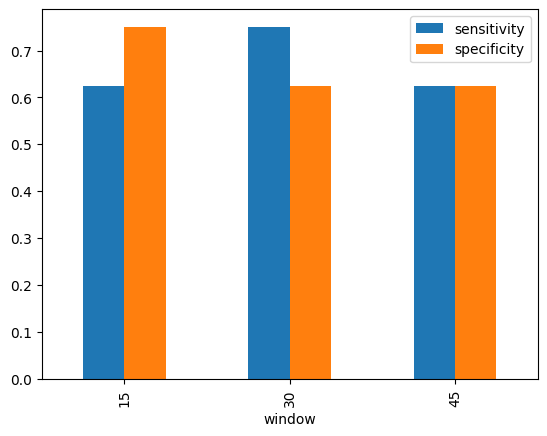

In [69]:
#Plot the results from the CNN above 

summary = results.groupby("window")[["sensitivity", "specificity"]].mean()
print(summary)

summary.plot(kind="bar")
plt.show()

In [90]:
#Look at testing within folds for each subjct 
fold_table = results.copy()
fold_table["fold"] -= 2
fold_table["sensitivity"] = fold_table["sensitivity"].round(3)
fold_table["specificity"] = fold_table["specificity"].round(3)
fold_table[["subject", "window", "fold", "sensitivity", "specificity"]]
fold_table


,subject,window,fold,sensitivity,specificity
0,chb01,15,1,1.0,1.0
0,chb01,15,2,0.0,1.0
0,chb01,15,3,1.0,0.0
0,chb01,15,4,1.0,1.0
0,chb01,30,1,1.0,0.0
0,chb01,30,2,1.0,0.0
0,chb01,30,3,1.0,1.0
0,chb01,30,4,1.0,1.0
0,chb01,45,1,1.0,0.0
0,chb01,45,2,1.0,1.0


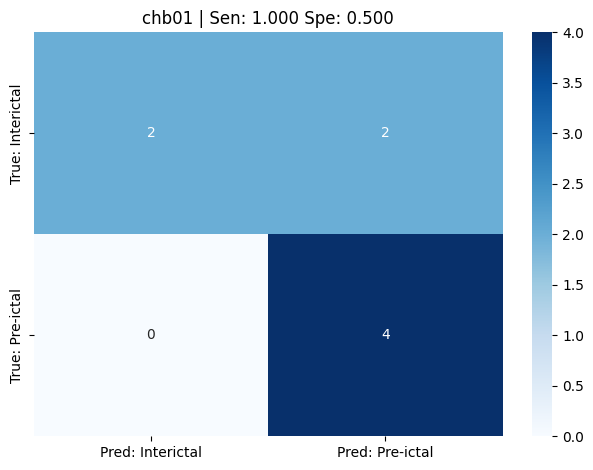

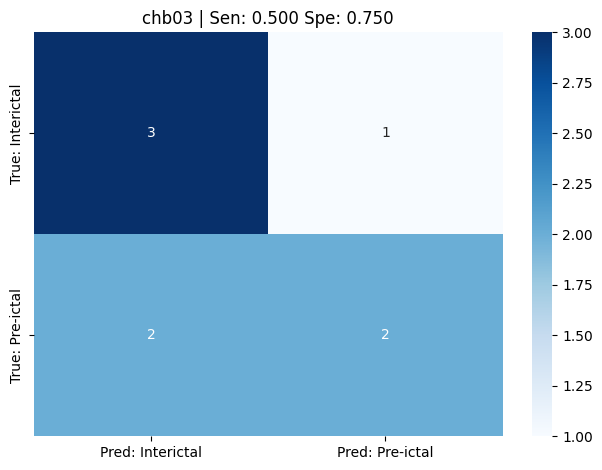

In [85]:
# I used an LLM to help me plot this 
for subject in subjects:
    subset = results[(results["subject"] == subject) & (results["window"] == "30")]
    tp = round(subset["sensitivity"].mean() * len(subset))
    tn = round(subset["specificity"].mean() * len(subset))
    cm = np.array([[tn, len(subset)-tn], [len(subset)-tp, tp]])

#subject specific heatmaps for their testing 
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Pred: Interictal", "Pred: Pre-ictal"],
                yticklabels=["True: Interictal", "True: Pre-ictal"])
    plt.title(f"{subject} | Sen: {subset['sensitivity'].mean()} Spe: {subset['specificity'].mean()}")
    plt.tight_layout()
    plt.show()

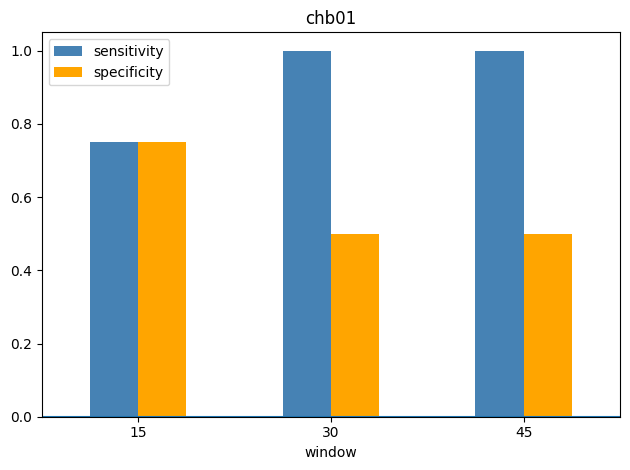

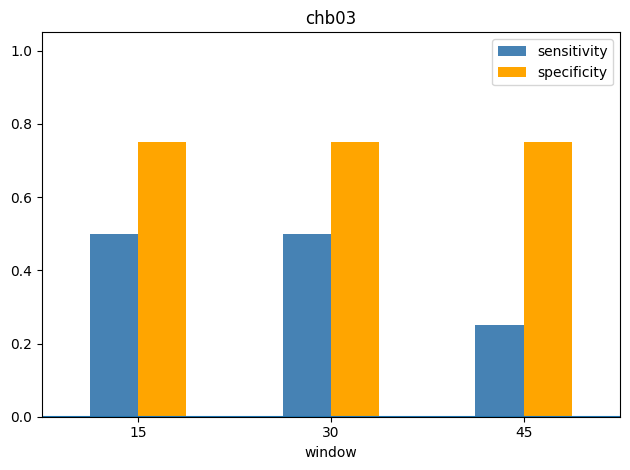

In [87]:
#subject level performatce mean summaries 
summary = results.groupby(["subject", "window"])[["sensitivity", "specificity"]].mean()

for subject in subjects:
    summary.loc[subject].plot(kind="bar", rot=0, color=["steelblue", "orange"], ylim=(0, 1.05))
    plt.axhline()
    plt.title(subject)
    plt.tight_layout()
    plt.show()

The 30 minute window performs the best with the highest sensitivity and specificity compared to 15 and 45 minute pre-ictal periods. 

# Autoregressive (AR) baseline model

This is our baseline model. 

In [70]:
#This code is similar to the code above as in it tests different window lengths and uses rolling cross validation and prediction 
#the AR model is used as a feature extractor and a logistic regression is used as a classifier with the coefficients fromt he AR model 
ar_results = pd.DataFrame()
for ar_order in range(3, 7): #I wasn't sure what AR(p) to begin with, hence I tested 3-7 for later comparison 

    for subject in subjects:

        for window_label, window_length in pre_ictal_windows.items(): #like before, I have to test out 15 minutes 30 minute, and 45 minute pre-ictal windows 
            data = data_full[(data_full["subject"] == subject) & (data_full["window"] == window_label)]
            seizure_files = full_data_frame[full_data_frame["subject"] == subject]["file"].tolist()

            for i in range(3, len(seizure_files)):
                pre_ictal_train = data[(data["file"].isin(seizure_files[:i])) & (data["label"] == 1)] #pre-ictal data is labeled as 1
                pre_ictal_test = data[(data["file"].isin(seizure_files[i:i+1])) & (data["label"] == 1)] #pre-ictal data is labeled as 1
                interictal = data[data["label"] == 0]

                train_dat = pd.concat([pre_ictal_train, interictal.sample(n=len(pre_ictal_train))]) #make sure to get the same amount of intericatl data are pre-ictal data
                test_dat = pd.concat([pre_ictal_test, interictal.sample(n=len(pre_ictal_test))]) #make sure to get the same amount of intericatl data are pre-ictal data
                
                X_train, y_train = reshape_for_cnn(train_dat) #Like before, we need to reshape the data
                X_test, y_test = reshape_for_cnn(test_dat) #Like before, we need to reshape the data

                #for each window the average across the 14 channels we are using are utilized to fit the AR model and extract the coefficients as features 
                #we expect the preictal and interictal windows to have different coefficients as they should show different patterns 
                feats_tr = np.array([AutoReg(w.mean(axis=0), lags=ar_order).fit().params for w in X_train])
                feats_te = np.array([AutoReg(w.mean(axis=0), lags=ar_order).fit().params for w in X_test])
                
                #Logistic regression is used in binary classification 
                clf = LogisticRegression(max_iter=1000, class_weight='balanced') #say the classes are balanced and set a max iteration for converges 
                clf.fit(feats_tr, y_train)
                preds = clf.predict(feats_te)

                #save the results for true negatives, true positives, false positive, and false negatives 
                tn, fp, fn, tp = confusion_matrix(y_test, preds, labels=[0, 1]).ravel()

                #save the results in a dataframe like before for easy access
                ar_results = pd.concat([ar_results, pd.DataFrame([{
                    "ar_order": ar_order,
                    "window": window_label,
                    "sensitivity": tp / (tp + fn) if (tp + fn) > 0 else 0.0,
                    "specificity": tn / (tn + fp) if (tn + fp) > 0 else 0.0 }])])





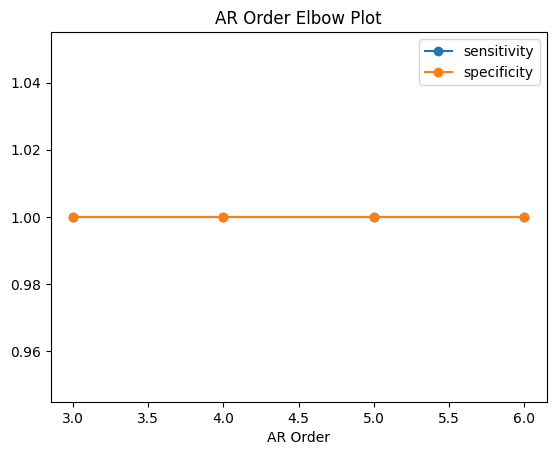

In [71]:
ar_results.groupby("ar_order")[["sensitivity", "specificity"]].mean().plot(marker="o")
plt.title("AR Order Elbow Plot")
plt.xlabel("AR Order")
plt.show()

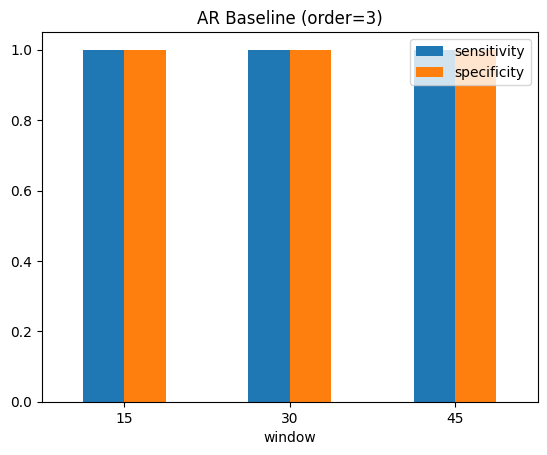

In [72]:
ar_results[ar_results["ar_order"] == 3].groupby("window")[["sensitivity", "specificity"]].mean().plot(kind="bar", rot=0)
plt.title("AR Baseline (order=3)")
plt.show()

# Question 2: PSD analysis 

In [73]:
#We need to select the channels that are not influence by blinking artifacts because that would introduce excess noise to out data
channels = ['T7-P7', 'P7-O1', 'F3-C3', 'C3-P3', 'P3-O1', 'F4-C4', 'C4-P4', 'P4-O2', 'T8-P8-0', 'P8-O2', 'FZ-CZ', 'CZ-PZ', 'P7-T7', 'T8-P8-1']

# Get 30 min pre-ictal data
pre_ictal_30 = data_full[(data_full["window"] == "30") & (data_full["label"] == 1)]

# Get ictal data from full_data_frame
ictal_data = {}
for subject in subjects:
    seizure = full_data_frame[full_data_frame["subject"] == subject] #get the seizure information for each subject 
    ictal_rows = [] #get the ictal rows (where the seizures happen)
    #Load in each of the seizure files and extrac just those periods based on the labeled onset and offset times
    for _, row in seizure.iterrows():
        df = load_in_edf_files(directory / subject / (row["file"] + ".edf"))
        ictal = df[(df["time"] >= row["onset_time"]) & (df["time"] < row["offset_time"])]
        ictal_rows.append(ictal)
    #save the data
    ictal_data[subject] = pd.concat(ictal_rows)



/var/folders/hv/mvjv6tk12gv9l0fgf4wnr2b00000gn/T/ipykernel_86636/2114312909.py:9: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw(str(file_path), preload = True)
/var/folders/hv/mvjv6tk12gv9l0fgf4wnr2b00000gn/T/ipykernel_86636/2114312909.py:9: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw(str(file_path), preload = True)
/var/folders/hv/mvjv6tk12gv9l0fgf4wnr2b00000gn/T/ipykernel_86636/2114312909.py:9: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw(str(file_path), preload = True)
/var/folders/hv/mvjv6tk12gv9l0fgf4wnr2b00000gn/T/ipykernel_86636/2114312909.py:9: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw(

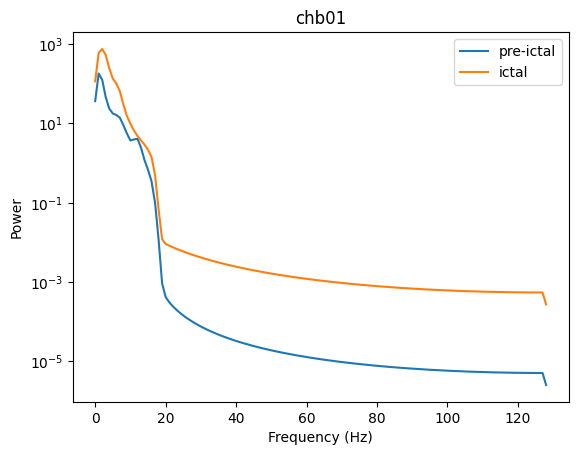

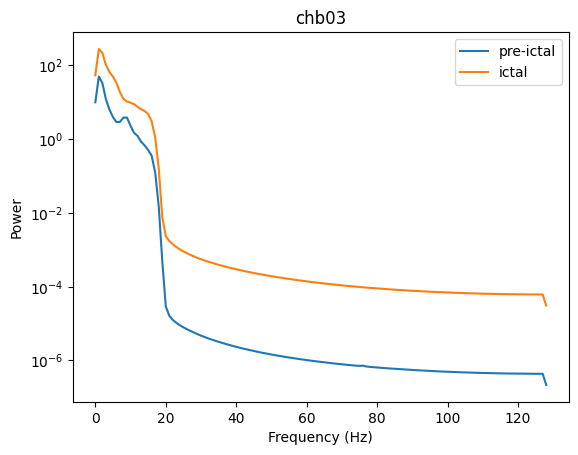

In [74]:
# Plot PSD for each subject
for subject in subjects:
    frequencies_preictal, psd_preictal = welch(pre_ictal_30[pre_ictal_30["subject"] == subject][channels].values.T.mean(axis=0), fs=freq)
    frequencies_ictal, psd_ictal = welch(ictal_data[subject][channels].values.T.mean(axis=0), fs=freq)
    plt.figure()
    plt.semilogy(frequencies_preictal, psd_preictal, label="pre-ictal")
    plt.semilogy(frequencies_ictal, psd_ictal, label="ictal")
    plt.title(subject)
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Power")
    plt.legend()
    plt.show()


In [75]:
# Jensen-Shannon divergence between pre-ictal and ictal PSD
#I have used Jensen-Shannon diverge to compare across two distict entities before, so I chose to do it for this project as well 
jsd_results = []
for subject in subjects:
    #get the preictal and ictal data for each subject and average is across the channels 
    preictal = pre_ictal_30[pre_ictal_30["subject"] == subject][channels].values.T
    ictal = ictal_data[subject][channels].values.T

    #We have to use Welche's method to get the PSD for the pre-ictal and ictal parts and we need to compare the power values 
    _, psd_pre = welch(preictal.mean(axis=0), fs=freq)
    _, psd_ict = welch(ictal.mean(axis=0), fs=freq)

    #To use Jensen-Shannon divergence, normalize the distributions 
    psd_pre = psd_pre / psd_pre.sum()
    psd_ict = psd_ict / psd_ict.sum()

    #Compute the Jensen-Shanno divergence
    jsd = jensenshannon(psd_pre, psd_ict)
    jsd_results.append({"subject": subject, "jsd": jsd})
    print(f"{subject} JSD: {jsd}")


chb01 JSD: 0.17129126915528942
chb03 JSD: 0.10265254709432046


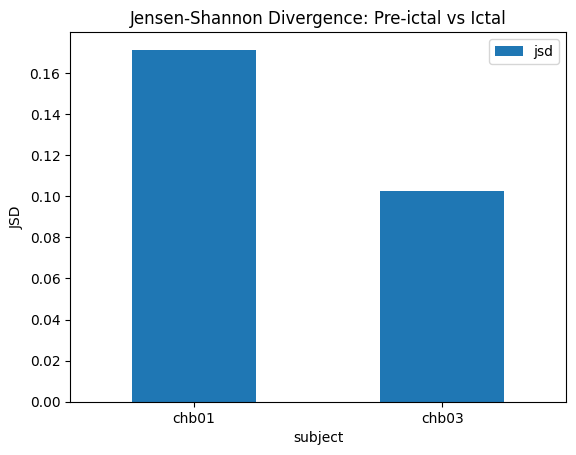

In [76]:
jsd_df = pd.DataFrame(jsd_results)
jsd_df.plot(x="subject", y="jsd", kind="bar", rot=0)
plt.title("Jensen-Shannon Divergence: Pre-ictal vs Ictal")
plt.ylabel("JSD")
plt.show()